<a href="https://colab.research.google.com/github/mehreenirfann/Brain-Tumor-Segmentation-and-Majority-Class-Classification/blob/main/BratS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install nibabel nilearn
!pip install kaggle
!pip install tqdm

# Mount Google Drive if saving processed data
from google.colab import drive

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 62.7 MB/s eta 0:00:00


In [ ]:

!kaggle datasets download -d dschettler8845/brats-2021-task1
!unzip brats-2021-task1.zip -d /content/brats2021



Dataset URL: https://www.kaggle.com/datasets/dschettler8845/brats-2021-task1
License(s): copyright-authors
100% 12.3G/12.3G [01:41<00:00, 131MB/s]

Archive:  brats-2021-task1.zip
  inflating: /content/brats2021/BraTS2021_00495.tar  
  inflating: /content/brats2021/BraTS2021_00621.tar  
  inflating: /content/brats2021/BraTS2021_Training_Data.tar  


Import Libraries

In [ ]:

import os
import numpy as np
import nibabel as nib
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import random
from scipy.ndimage import zoom

Data Extraction - only keep files from real patients

In [ ]:
import os, tarfile
from pathlib import Path

DATA_DIR_RAW   = '/content/brats2021'
EXTRACT_DIR    = '/content/brats2021_extracted'
TARGET_SIZE    = (128, 128)
MODALITIES     = ['t1', 't1ce', 't2', 'flair']

Path(EXTRACT_DIR).mkdir(exist_ok=True)

for tar_path in sorted(Path(DATA_DIR_RAW).glob('*.tar')):
    print(f"Extracting {tar_path.name}...")
    with tarfile.open(tar_path) as tar:
        tar.extractall(EXTRACT_DIR)
    print(f"  Done.")


all_patients = sorted([
    str(p) for p in Path(EXTRACT_DIR).rglob('BraTS2021_*')
    if p.is_dir() and list(p.glob('*_t1.nii.gz'))
])

print(f"\nFound {len(all_patients)} patients")
print("Sample:", all_patients[:2])

DATA_DIR = EXTRACT_DIR

Extracting BraTS2021_00495.tar...
  Done.
Extracting BraTS2021_00621.tar...
  Done.
Extracting BraTS2021_Training_Data.tar...


/tmp/ipykernel_19616/134822351.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(EXTRACT_DIR)


  Done.

Found 1251 patients
Sample: ['/content/brats2021_extracted/BraTS2021_00000', '/content/brats2021_extracted/BraTS2021_00002']


Data conversion and cleaning - convert from .nii.gz to numpy arrays + ensuring all 4 modalities are present + save height, width and depth (number of 2D slices) of each image as well as the segmentation mask (labeling image with tumor segments)

In [ ]:

def load_patient(patient_dir):
    patient_dir = Path(patient_dir)
    pid = patient_dir.name

    volumes = {}
    for mod in MODALITIES:
        path = patient_dir / f'{pid}_{mod}.nii.gz'
        volumes[mod] = nib.load(str(path)).get_fdata()

    seg_path = patient_dir / f'{pid}_seg.nii.gz'
    seg = nib.load(str(seg_path)).get_fdata()
    return volumes, seg

Z score normalisation to standardise data

In [ ]:

def normalize(volume):
    mask = volume > 0
    mean = volume[mask].mean()
    std  = volume[mask].std()
    normed = np.zeros_like(volume, dtype=np.float32)
    normed[mask] = (volume[mask] - mean) / (std + 1e-8)
    return normed

Data filtering - removing the redundancet slices (ones that dont contain tumor pixels) + looping through the depth (3D) to reduce dimentions to 2D across all 4 modalities (stacking) + resizing and interpolation

In [ ]:

def is_valid_slice(seg_slice, min_tumor_pixels=20):
    return np.sum(seg_slice > 0) >= min_tumor_pixels

def extract_2d_slices(volumes, seg, target_size=TARGET_SIZE):
    D = seg.shape[2]
    slices_X, slices_y = [], []

    for d in range(D):
        seg_slice = seg[:, :, d]
        if not is_valid_slice(seg_slice):
            continue


        channels = []
        for mod in MODALITIES:
            sl = volumes[mod][:, :, d]

            scale = (target_size[0]/sl.shape[0], target_size[1]/sl.shape[1])
            sl_resized = zoom(sl, scale, order=1)
            channels.append(sl_resized)

        x = np.stack(channels, axis=0).astype(np.float32)

        seg_resized = zoom(seg_slice, scale, order=0)
        slices_X.append(x)
        slices_y.append(seg_resized.astype(np.int64))

    return slices_X, slices_y


Checking the Preprocessing data:
1. Visual checks - check slices for all 4 modalities + the segmentation mask for all three types of tumors
2. statistical checks - ideally through z score normalisation we need mean = 0 and std = 1, checking for those
3. Class probability checks

   PREPROCESSING SUMMARY
Total valid slices:      47
Input shape per slice:   (4, 128, 128)
Mask shape per slice:    (128, 128)

-- Intensity stats (should be ~N(0,1)) --
  t1      mean=0.040  std=0.484  min=-4.406  max=5.147
  t1ce    mean=0.034  std=0.506  min=-2.139  max=11.840
  t2      mean=0.037  std=0.554  min=-1.774  max=5.401
  flair   mean=0.029  std=0.542  min=-2.665  max=5.111

-- Segmentation label distribution --
  Label 0 (Background):    753,907 pixels  (97.90%)
  Label 1 (NCR/NET   ):      3,332 pixels  (0.43%)
  Label 2 (ED        ):      3,608 pixels  (0.47%)
  Label 3 (ET        ):      9,201 pixels  (1.19%)


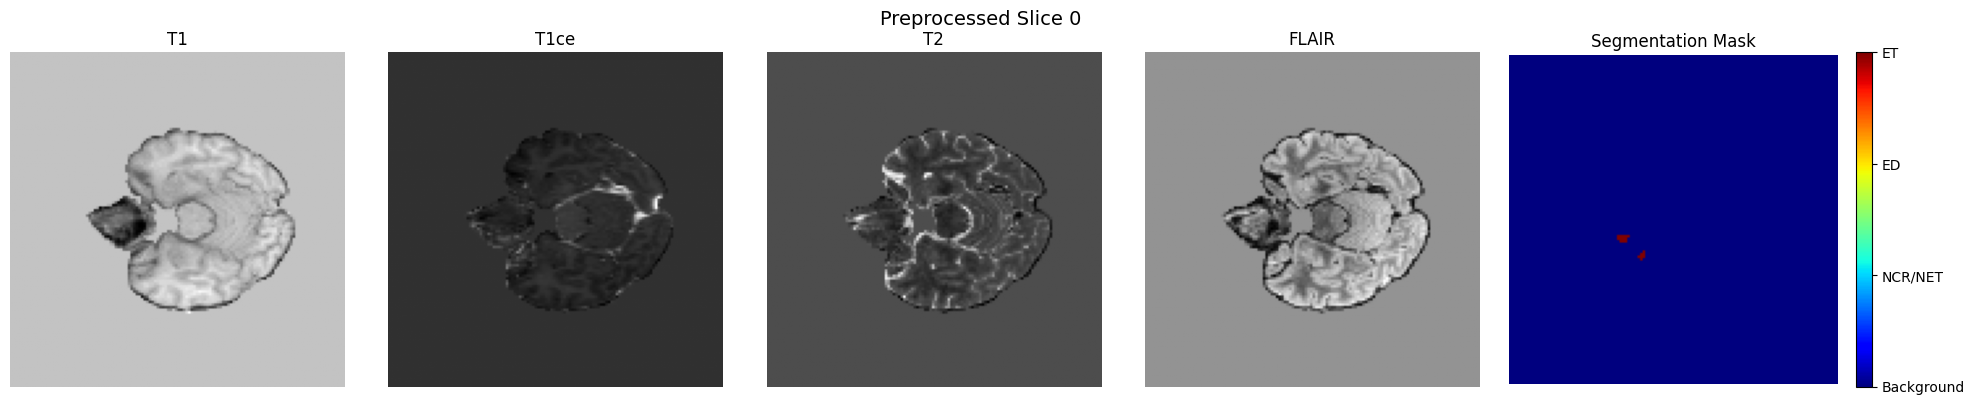

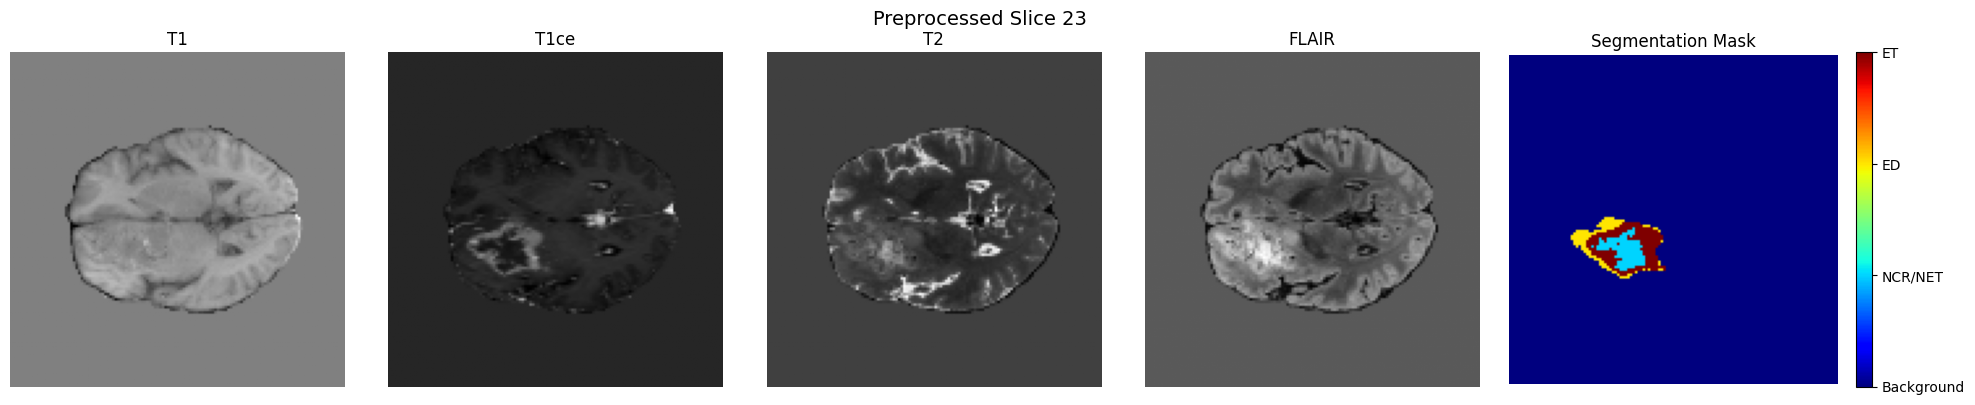

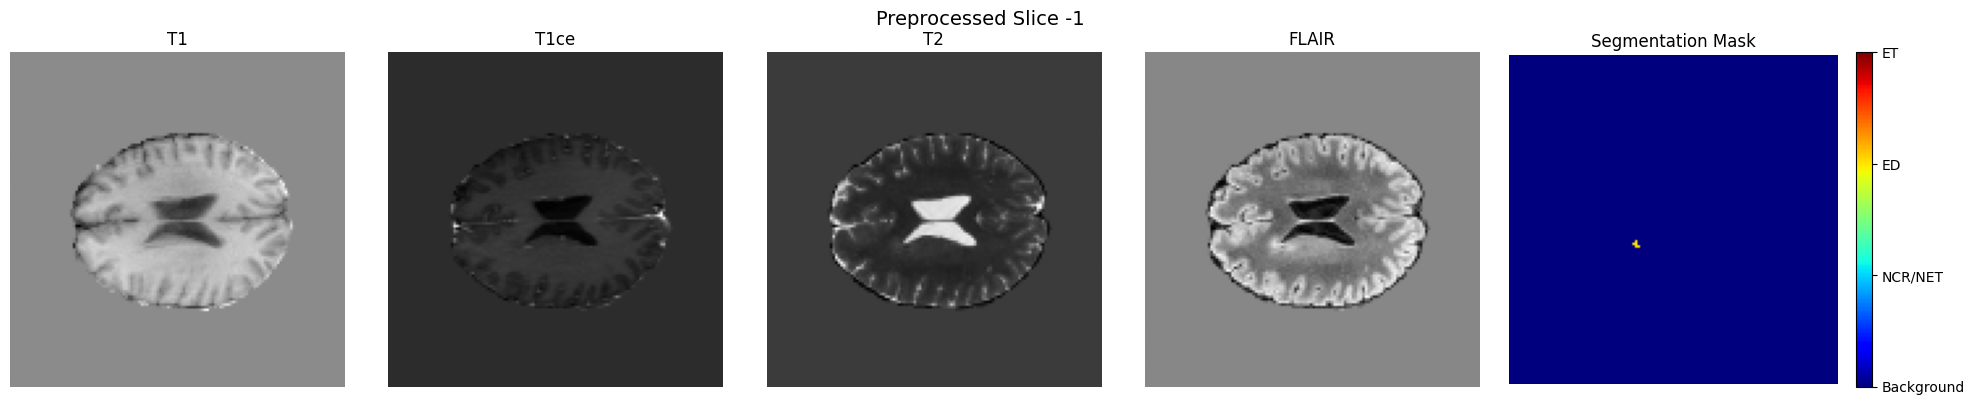

In [ ]:

import matplotlib.pyplot as plt

def visualize_preprocessed_sample(slices_X, slices_y, slice_idx=0):

    x = slices_X[slice_idx]  # (4, H, W)
    y = slices_y[slice_idx]  # (H, W)

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    titles = ['T1', 'T1ce', 'T2', 'FLAIR', 'Segmentation Mask']

    for i in range(4):
        axes[i].imshow(x[i], cmap='gray')
        axes[i].set_title(titles[i])
        axes[i].axis('off')

    axes[4].imshow(y, cmap='jet', vmin=0, vmax=3)
    axes[4].set_title('Segmentation Mask')
    axes[4].axis('off')

    cbar = plt.colorbar(axes[4].images[0], ax=axes[4], fraction=0.046)
    cbar.set_ticks([0, 1, 2, 3])
    cbar.set_ticklabels(['Background', 'NCR/NET', 'ED', 'ET'])

    plt.suptitle(f'Preprocessed Slice {slice_idx}', fontsize=14)
    plt.tight_layout()
    plt.show()

def print_preprocessing_stats(slices_X, slices_y):
    x_all = np.stack(slices_X)  # (N, 4, H, W)
    y_all = np.stack(slices_y)  # (N, H, W)

    print("   PREPROCESSING SUMMARY")
    print(f"Total valid slices:      {len(slices_X)}")
    print(f"Input shape per slice:   {slices_X[0].shape}")  # (4, 128, 128)
    print(f"Mask shape per slice:    {slices_y[0].shape}")  # (128, 128)
    print(f"\n-- Intensity stats (should be ~N(0,1)) --")
    for i, mod in enumerate(MODALITIES):
        data = x_all[:, i, :, :]
        print(f"  {mod:6s}  mean={data.mean():.3f}  std={data.std():.3f}  min={data.min():.3f}  max={data.max():.3f}")
    print(f"\n-- Segmentation label distribution --")
    unique, counts = np.unique(y_all, return_counts=True)
    total = y_all.size
    for u, c in zip(unique, counts):
        label = ['Background', 'NCR/NET', 'ED', 'ET'][int(u)]
        print(f"  Label {int(u)} ({label:10s}): {c:>10,} pixels  ({100*c/total:.2f}%)")
    print("=" * 40)

#sample summary

sample_patient = all_patients[0]
volumes, seg = load_patient(sample_patient)


seg[seg == 4] = 3

volumes = {m: normalize(v) for m, v in volumes.items()}
slices_X, slices_y = extract_2d_slices(volumes, seg)


print_preprocessing_stats(slices_X, slices_y)


for idx in [0, len(slices_X)//2, -1]:
    visualize_preprocessed_sample(slices_X, slices_y, slice_idx=idx)


Applying the preprocessing pipeline on the entire dataset (all patients)

In [ ]:

import time, gc

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

PROCESSED_DIR = '/content/processed_slices'
os.makedirs(PROCESSED_DIR, exist_ok=True)

metadata = []
total_slices = 0
start_time = time.time()

for patient_idx, patient_dir in enumerate(all_patients):
    if patient_idx % 50 == 0:
        elapsed = time.time() - start_time
        print(f"Processing patient {patient_idx}/{len(all_patients)} "
              f"({elapsed:.0f}s elapsed, {total_slices} slices so far)")

    volumes, seg = load_patient(patient_dir)
    seg[seg == 4] = 3
    volumes = {m: normalize(v) for m, v in volumes.items()}
    slices_X, slices_y = extract_2d_slices(volumes, seg)

    if len(slices_X) == 0:
        del volumes, seg, slices_X, slices_y
        continue

    npz_path = os.path.join(PROCESSED_DIR, f'patient_{patient_idx:04d}.npz')
    np.savez_compressed(npz_path,
                        X=np.stack(slices_X),
                        y=np.stack(slices_y))

    metadata.append({
        'patient_idx': patient_idx,
        'npz_path': npz_path,
        'num_slices': len(slices_X),
    })
    total_slices += len(slices_X)

    # Free memory immediately
    del volumes, seg, slices_X, slices_y
    if patient_idx % 100 == 0:
        gc.collect()

elapsed = time.time() - start_time
print(f"\nDone! Processed {len(all_patients)} patients in {elapsed:.0f}s")
print(f"Patients with valid slices: {len(metadata)}")
print(f"Total valid slices saved to disk: {total_slices}")
print(f"Slices per patient (avg): {total_slices / max(len(metadata), 1):.1f}")
gc.collect()

Processing patient 0/1251 (0s elapsed, 0 slices so far)
Processing patient 50/1251 (96s elapsed, 3094 slices so far)
Processing patient 100/1251 (193s elapsed, 6415 slices so far)
Processing patient 150/1251 (289s elapsed, 9590 slices so far)
Processing patient 200/1251 (383s elapsed, 12564 slices so far)
Processing patient 250/1251 (473s elapsed, 15472 slices so far)
Processing patient 300/1251 (566s elapsed, 18619 slices so far)
Processing patient 350/1251 (658s elapsed, 21851 slices so far)
Processing patient 400/1251 (751s elapsed, 25108 slices so far)
Processing patient 450/1251 (853s elapsed, 28329 slices so far)
Processing patient 500/1251 (945s elapsed, 31658 slices so far)
Processing patient 550/1251 (1039s elapsed, 34678 slices so far)
Processing patient 600/1251 (1144s elapsed, 37905 slices so far)
Processing patient 650/1251 (1240s elapsed, 41114 slices so far)
Processing patient 700/1251 (1334s elapsed, 44428 slices so far)
Processing patient 750/1251 (1426s elapsed, 47598

240

Applying Train, test, validation split (80/10/10)

In [ ]:

from sklearn.model_selection import train_test_split

patient_idxs = list(range(len(metadata)))

train_pats, temp_pats = train_test_split(
    patient_idxs, test_size=0.2, random_state=42
)
val_pats, test_pats = train_test_split(
    temp_pats, test_size=0.5, random_state=42
)

print(f"Patient split: {len(train_pats)} train, "
      f"{len(val_pats)} val, {len(test_pats)} test")

def build_slice_index(pat_indices):
    index = []
    for pi in pat_indices:
        m = metadata[pi]
        for s in range(m['num_slices']):
            index.append((m['npz_path'], s))
    return index

train_index = build_slice_index(train_pats)
val_index   = build_slice_index(val_pats)
test_index  = build_slice_index(test_pats)

import random as _random
_random.seed(42)
train_index = _random.sample(train_index, int(len(train_index) * 0.3))
val_index   = _random.sample(val_index,   int(len(val_index)   * 0.3))
test_index  = _random.sample(test_index,  int(len(test_index)  * 0.3))

print(f"Slice split: {len(train_index)} train, "
      f"{len(val_index)} val, {len(test_index)} test")
print(f"Total: {len(train_index) + len(val_index) + len(test_index)}")

Patient split: 1000 train, 125 val, 126 test
Slice split: 18920 train, 2374 val, 2436 test
Total: 23730


Memory optimisation (required since the dataset is HUGE) - keeping only the last 10 patients in memories (LRU cache) Data augmentation, fixes with the angles, flips, intensity shifts + nearest neighbours interpolation (Applied only on Training data)

In [ ]:

from torchvision.transforms import InterpolationMode

class BraTSDataset(Dataset):

    def __init__(self, slice_index, augment=False, cache_size=10):
        self.slice_index = slice_index
        self.augment = augment
        self._cache = {}
        self._cache_order = []
        self._max_cache = cache_size

    def __len__(self):
        return len(self.slice_index)

    def _load_patient(self, npz_path):
        if npz_path not in self._cache:
            data = np.load(npz_path)
            self._cache[npz_path] = (data['X'], data['y'])
            self._cache_order.append(npz_path)
            # Evict oldest entries when cache is full
            while len(self._cache_order) > self._max_cache:
                old_key = self._cache_order.pop(0)
                if old_key in self._cache:
                    del self._cache[old_key]
        return self._cache[npz_path]

    def __getitem__(self, idx):
        npz_path, slice_idx = self.slice_index[idx]
        X_all, y_all = self._load_patient(npz_path)

        image = torch.from_numpy(X_all[slice_idx].copy())  # (4, 128, 128)
        mask  = torch.from_numpy(y_all[slice_idx].copy())   # (128, 128)

        if self.augment:
            image, mask = self._apply_augmentation(image, mask)

        return image, mask.long()

    def _apply_augmentation(self, image, mask):
        mask = mask.unsqueeze(0).float()  # (1, H, W)

        # horizontal
        if random.random() > 0.5:
            image = TF.hflip(image)
            mask  = TF.hflip(mask)

        # verticle
        if random.random() > 0.5:
            image = TF.vflip(image)
            mask  = TF.vflip(mask)

        # rotation
        angle = random.uniform(-15, 15)
        image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR)
        mask  = TF.rotate(mask,  angle, interpolation=InterpolationMode.NEAREST)

        mask = mask.squeeze(0).long()

        # intensity scaling
        if random.random() > 0.5:
            scale = random.uniform(0.9, 1.1)
            shift = random.uniform(-0.1, 0.1)
            image = image * scale + shift

        return image, mask


train_dataset = BraTSDataset(train_index, augment=True, cache_size=10)
val_dataset   = BraTSDataset(val_index,   augment=False, cache_size=10)
test_dataset  = BraTSDataset(test_index,  augment=False, cache_size=10)

print(f"Train dataset: {len(train_dataset)} slices")
print(f"Val dataset:   {len(val_dataset)} slices")
print(f"Test dataset:  {len(test_dataset)} slices")

img, msk = train_dataset[0]
print(f"\nSample — image: {img.shape}, {img.dtype} | mask: {msk.shape}, {msk.dtype}")
print(f"Mask unique values: {msk.unique().tolist()}")

Train dataset: 18920 slices
Val dataset:   2374 slices
Test dataset:  2436 slices

Sample — image: torch.Size([4, 128, 128]), torch.float32 | mask: torch.Size([128, 128]), torch.int64
Mask unique values: [0, 2]


create batches to work with batch learning instead of online (less processing time) + shuffling of data to prevent overfitting + parallel processing

In [ ]:

def get_dataloaders(train_dataset, val_dataset, test_dataset,
                    batch_size=40, num_workers=2):
    pin = torch.cuda.is_available()

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size,
        shuffle=True, num_workers=num_workers, pin_memory=pin
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size,
        shuffle=False, num_workers=num_workers, pin_memory=pin
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size,
        shuffle=False, num_workers=num_workers, pin_memory=pin
    )

    return train_loader, val_loader, test_loader


BATCH_SIZE = 32
train_loader, val_loader, test_loader = get_dataloaders(
    train_dataset, val_dataset, test_dataset, batch_size=BATCH_SIZE
)

print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Batch size: 32
Train batches: 592
Val batches:   75
Test batches:  77


Implementation of UNET architecture - 2 3x3 convolutions followed by ReLU activation as well as batch normalisation (restandardisation of data), encoding (feature extraction), decoding (reconstruction)

In [ ]:

import torch.nn as nn

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet2D(nn.Module):

    def __init__(self, in_channels=4, num_classes=4):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)   # 512 skip + 512 upsampled = 1024 in
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)    # 256 skip + 256 upsampled = 512 in
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)    # 128 skip + 128 upsampled = 256 in
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)     # 64 skip + 64 upsampled = 128 in

        # Output layer
        self.out_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)                    # (B, 64, 128, 128)
        e2 = self.enc2(self.pool(e1))         # (B, 128, 64, 64)
        e3 = self.enc3(self.pool(e2))         # (B, 256, 32, 32)
        e4 = self.enc4(self.pool(e3))         # (B, 512, 16, 16)

        b = self.bottleneck(self.pool(e4))    # (B, 1024, 8, 8)

        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))   # (B, 512, 16, 16)
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))  # (B, 256, 32, 32)
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))  # (B, 128, 64, 64)
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))  # (B, 64, 128, 128)

        return self.out_conv(d1)              # (B, num_classes, 128, 128)



model = UNet2D(in_channels=4, num_classes=4)
dummy = torch.randn(2, 4, 128, 128)
out = model(dummy)
print(f"Input shape:  {dummy.shape}")
print(f"Output shape: {out.shape}")  # Should be torch.Size([2, 4, 128, 128])

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")
del model, dummy, out  # Free memory

Input shape:  torch.Size([2, 4, 128, 128])
Output shape: torch.Size([2, 4, 128, 128])
Trainable parameters: 31,038,404


Loss Functions

In [ ]:

class CombinedLoss(nn.Module):


    def __init__(self, ce_weight=0.5, dice_weight=1.5, class_weights=None,
                 smooth=1e-5):
        super().__init__()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight
        self.smooth = smooth

        if class_weights is not None:
            self.ce_loss = nn.CrossEntropyLoss(weight=class_weights)
        else:
            self.ce_loss = nn.CrossEntropyLoss()

    def _dice_loss(self, predictions, targets):

        num_classes = predictions.shape[1]
        probs = torch.softmax(predictions, dim=1)  # (B, C, H, W)

        # One-hot encode targets: (B, H, W) -> (B, C, H, W)
        targets_one_hot = torch.zeros_like(probs)
        targets_one_hot.scatter_(1, targets.unsqueeze(1), 1.0)

        dice_sum = 0.0
        # Compute dice for classes 1, 2, 3 (skip background class 0)
        for c in range(1, num_classes):
            p = probs[:, c].reshape(-1)
            g = targets_one_hot[:, c].reshape(-1)
            intersection = (p * g).sum()
            dice_c = (2.0 * intersection + self.smooth) / \
                     (p.sum() + g.sum() + self.smooth)
            dice_sum += dice_c

        mean_dice = dice_sum / (num_classes - 1)
        return 1.0 - mean_dice

    def forward(self, predictions, targets):

        ce = self.ce_loss(predictions, targets)
        dice = self._dice_loss(predictions, targets)
        return self.ce_weight * ce + self.dice_weight * dice


# Verification with dummy data
criterion = CombinedLoss()
dummy_pred = torch.randn(2, 4, 128, 128)
dummy_target = torch.randint(0, 4, (2, 128, 128))
loss = criterion(dummy_pred, dummy_target)
print(f"Combined loss on dummy data: {loss.item():.4f}")
del criterion, dummy_pred, dummy_target, loss

Combined loss on dummy data: 1.9849


Class imbalance solution
1. pixel level frequency of each class
2. Inverse weights as per the frequency (more weight to smaller freq classes)
3. penalty using cross enropy

In [ ]:

NUM_CLASSES = 4
label_names = {0: 'Background', 1: 'NCR/NET', 2: 'Edema', 3: 'Enhancing Tumor'}

class_counts = np.zeros(NUM_CLASSES, dtype=np.int64)

for pi in train_pats:
    m = metadata[pi]
    data = np.load(m['npz_path'])
    y = data['y']  # (num_slices, H, W)
    for c in range(NUM_CLASSES):
        class_counts[c] += np.sum(y == c)

total_pixels = class_counts.sum()

print("Training set class distribution:")
for c in range(NUM_CLASSES):
    pct = 100 * class_counts[c] / total_pixels
    print(f"  Class {c} ({label_names[c]:15s}): {class_counts[c]:>12,} pixels ({pct:.2f}%)")

class_freqs = class_counts / total_pixels
class_weights = 1.0 / np.log(1.1 + class_freqs)
class_weights = torch.tensor(class_weights / class_weights.sum() * NUM_CLASSES, dtype=torch.float32)

print(f"\nComputed class weights: {[f'{w:.4f}' for w in class_weights.tolist()]}")
print(f"  Sum = {class_weights.sum().item():.2f}")

Training set class distribution:
  Class 0 (Background     ): 1,006,494,756 pixels (97.40%)
  Class 1 (NCR/NET        ):    4,036,904 pixels (0.39%)
  Class 2 (Edema          ):   16,764,890 pixels (1.62%)
  Class 3 (Enhancing Tumor):    6,025,946 pixels (0.58%)

Computed class weights: ['0.1796', '1.3257', '1.1919', '1.3027']
  Sum = 4.00


In [1]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}\n")

model = UNet2D(in_channels=4, num_classes=4).to(device)
criterion = CombinedLoss(
    ce_weight=0.5, dice_weight=1.5,
    class_weights=class_weights.to(device)
).to(device)

images, masks = next(iter(train_loader))
images, masks = images.to(device), masks.to(device)

outputs = model(images)
loss = criterion(outputs, masks)
loss.backward()

print(f"Input shape:  {images.shape}")    # (B, 4, 128, 128)
print(f"Output shape: {outputs.shape}")   # (B, 4, 128, 128)
print(f"Loss value:   {loss.item():.4f}")
print(f"Backward pass OK — gradients computed successfully.")
print(f"\n{'='*50}")
print(f"  Segmentation Part 1 COMPLETE — ready for handoff")
print(f"{'='*50}")
print(f"\nAvailable for Part 2:")
print(f"  - train_loader, val_loader, test_loader")
print(f"  - UNet2D(in_channels=4, num_classes=4)")
print(f"  - CombinedLoss(ce_weight, dice_weight, class_weights)")
print(f"  - class_weights tensor")
print(f"  - test_dataset / test_loader for final evaluation")

NameError: name 'torch' is not defined

**Segmentation 2**

Here we start the training and evaluation

We calculate her the appropriate **metrics for a UNet model:**
- Pixel Accuracy
- IoU
- Dice score

We will need them for measuring how the model’s mask aligns with real tumor

In [ ]:

import torch

def calculate_metrics(outputs, targets, num_classes=4, smooth=1e-6):
    preds = torch.argmax(outputs, dim=1)

    correct = (preds == targets).sum().item()
    total = targets.numel()
    accuracy = correct / total

    iou_sum = 0.0
    dice_sum = 0.0

    for c in range(1, num_classes): # Skip background (0)
        pred_c = (preds == c)
        target_c = (targets == c)

        intersection = (pred_c & target_c).sum().float()
        union = (pred_c | target_c).sum().float()

        # IoU
        iou = (intersection + smooth) / (union + smooth)
        iou_sum += iou.item()

        # Dice Score
        dice = (2.0 * intersection + smooth) / (pred_c.sum().float() + target_c.sum().float() + smooth)
        dice_sum += dice.item()

    mean_iou = iou_sum / (num_classes - 1)
    mean_dice = dice_sum / (num_classes - 1)

    return accuracy, mean_iou, mean_dice

print("Evaluation metrics defined successfully.")

Evaluation metrics defined successfully.


In [ ]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = UNet2D(in_channels=4, num_classes=4)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model created. Trainable parameters: {total_params:,}")

Model created. Trainable parameters: 31,038,404


The training setup is done here, we're using optim library from torch to use the AdamW optimizer and scheduler. Schedular reduces learning rate when it plateus

In [ ]:

import torch.optim as optim

EPOCHS = 10
LEARNING_RATE = 0.001

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print(f"Training setup complete. Epochs: {EPOCHS}, LR: {LEARNING_RATE}")

Training setup complete. Epochs: 10, LR: 0.001


Training:

Keep an history of all epoch runs on the grades we have defined and we save the model with the best evals.

In [ ]:
import time
from tqdm import tqdm
from google.colab import drive
drive.mount('/content/drive')

best_val_loss = float('inf')
save_path = './best_unet_model.pth'
checkpoint_path = '/content/drive/MyDrive/checkpoint_latest.pth'

history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': []}

for epoch in range(EPOCHS):
    start_time = time.time()

    #training
    model.train()
    train_loss = 0.0

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    for images, masks in train_loop:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)

    #validation
    model.eval()
    val_loss, val_acc, val_iou, val_dice = 0.0, 0.0, 0.0, 0.0

    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]")

    with torch.no_grad():
        for images, masks in val_loop:
            images, masks = images.to(device), masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            val_loss += loss.item()

            acc, iou, dice = calculate_metrics(outputs, masks)
            val_acc += acc
            val_iou += iou
            val_dice += dice

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = val_acc / len(val_loader)
    avg_val_iou = val_iou / len(val_loader)
    avg_val_dice = val_dice / len(val_loader)

    scheduler.step(avg_val_loss)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_dice'].append(avg_val_dice)
    history['val_iou'].append(avg_val_iou)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), save_path)
        saved_msg = " -> [MODEL SAVED]"
    else:
        saved_msg = ""

    # Her epoch sonunda Drive'a kaydet
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_loss': best_val_loss,
        'history': history,
    }, checkpoint_path)
    print(f"Checkpoint kaydedildi -> {checkpoint_path}")

    elapsed = time.time() - start_time

    print(f"\n--- Epoch {epoch+1} Summary ({elapsed:.0f}s) ---")
    print(f"  Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}{saved_msg}")
    print(f"  Val Dice: {avg_val_dice:.4f} | Val IoU: {avg_val_iou:.4f} | Val Acc: {avg_val_acc:.4f}\n")

print("Training finished!")

Mounted at /content/drive


Epoch 1/10 [Val]: 100%|██████████| 75/75 [02:11<00:00,  1.75s/it]


Checkpoint kaydedildi -> /content/drive/MyDrive/checkpoint_latest.pth

--- Epoch 1 Summary (1332s) ---
  Train Loss: 0.6115 | Val Loss: 0.4268 -> [MODEL SAVED]
  Val Dice: 0.7764 | Val IoU: 0.6464 | Val Acc: 0.9923



Epoch 2/10 [Val]: 100%|██████████| 75/75 [02:11<00:00,  1.76s/it]


Checkpoint kaydedildi -> /content/drive/MyDrive/checkpoint_latest.pth

--- Epoch 2 Summary (1333s) ---
  Train Loss: 0.3855 | Val Loss: 0.3831 -> [MODEL SAVED]
  Val Dice: 0.8039 | Val IoU: 0.6829 | Val Acc: 0.9932



...

Checkpoint kaydedildi -> /content/drive/MyDrive/checkpoint_latest.pth

--- Epoch 8 Summary (1321s) ---
  Train Loss: 0.3162 | Val Loss: 0.3463 -> [MODEL SAVED]
  Val Dice: 0.8204 | Val IoU: 0.7052 | Val Acc: 0.9939



Epoch 9/10 [Val]: 100%|██████████| 75/75 [02:09<00:00,  1.72s/it]


Checkpoint kaydedildi -> /content/drive/MyDrive/checkpoint_latest.pth

--- Epoch 9 Summary (1323s) ---
  Train Loss: 0.3118 | Val Loss: 0.3365 -> [MODEL SAVED]
  Val Dice: 0.8243 | Val IoU: 0.7106 | Val Acc: 0.9940



Epoch 10/10 [Val]: 100%|██████████| 75/75 [02:11<00:00,  1.75s/it]


Checkpoint kaydedildi -> /content/drive/MyDrive/checkpoint_latest.pth

--- Epoch 10 Summary (1331s) ---
  Train Loss: 0.3078 | Val Loss: 0.3284 -> [MODEL SAVED]
  Val Dice: 0.8261 | Val IoU: 0.7135 | Val Acc: 0.9940

Training finished!


Testing our best model against our test data.

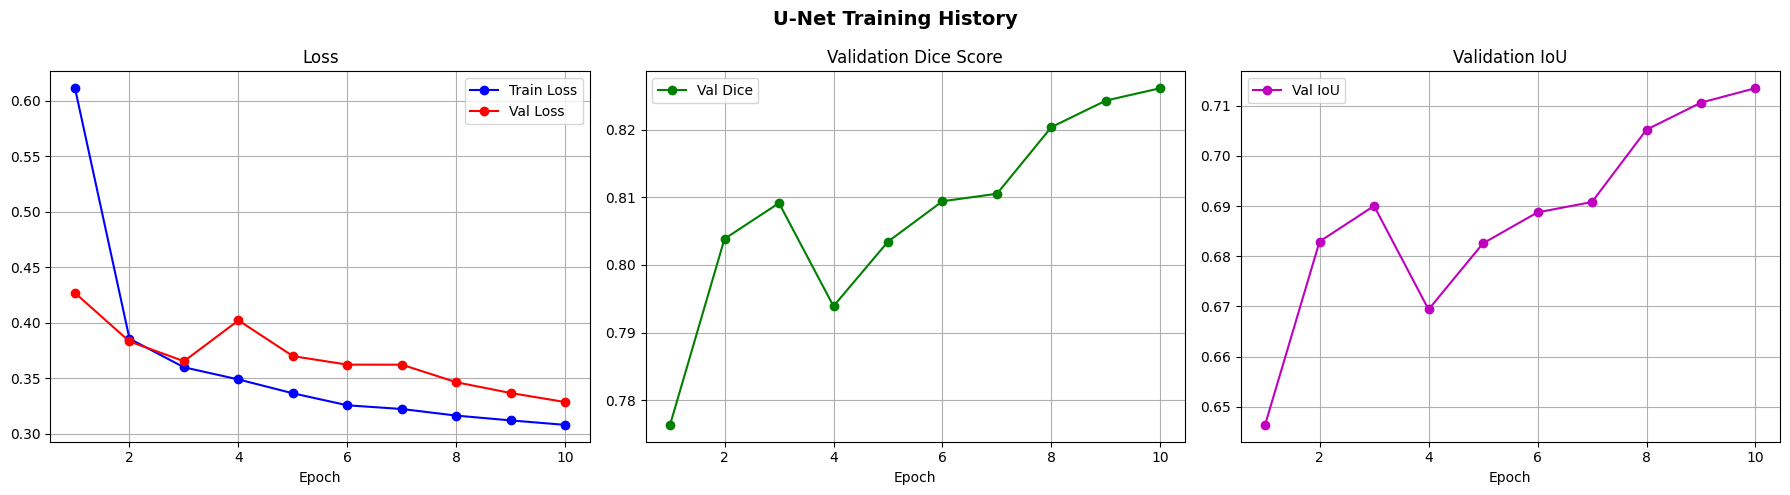

In [ ]:


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('U-Net Training History', fontsize=14, fontweight='bold')

epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'], 'r-o', label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, history['val_dice'], 'g-o', label='Val Dice')
axes[1].set_title('Validation Dice Score')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(epochs_range, history['val_iou'], 'm-o', label='Val IoU')
axes[2].set_title('Validation IoU')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:

print("Loading best model for testing...")
model.load_state_dict(torch.load(save_path))
model.eval()

test_loss, test_acc, test_iou, test_dice = 0.0, 0.0, 0.0, 0.0

with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        test_loss += loss.item()

        acc, iou, dice = calculate_metrics(outputs, masks)
        test_acc += acc
        test_iou += iou
        test_dice += dice

avg_test_loss = test_loss / len(test_loader)
avg_test_acc = test_acc / len(test_loader)
avg_test_iou = test_iou / len(test_loader)
avg_test_dice = test_dice / len(test_loader)


print("        FINAL TEST RESULTS           ")
print(f"Test Loss:       {avg_test_loss:.4f}")
print(f"Pixel Accuracy:  {avg_test_acc:.4f}")
print(f"Mean IoU:        {avg_test_iou:.4f}")
print(f"Mean Dice Score: {avg_test_dice:.4f}")


Loading best model for testing...
        FINAL TEST RESULTS           
Test Loss:       0.2912
Pixel Accuracy:  0.9942
Mean IoU:        0.7466
Mean Dice Score: 0.8504


In [ ]:
# Per-Class Dice and IoU for U-Net
import matplotlib.pyplot as plt

label_names_unet = {0: 'Background', 1: 'NCR/NET', 2: 'Edema', 3: 'Enhancing Tumor'}

model.load_state_dict(torch.load(save_path))
model.eval()

per_class_iou   = np.zeros(4)
per_class_dice  = np.zeros(4)
per_class_count = np.zeros(4)
smooth = 1e-6

with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        for c in range(1, 4):
            pred_c   = (preds == c)
            target_c = (masks == c)

            intersection = (pred_c & target_c).sum().float()
            union        = (pred_c | target_c).sum().float()

            iou  = (intersection + smooth) / (union + smooth)
            dice = (2.0 * intersection + smooth) / (pred_c.sum().float() + target_c.sum().float() + smooth)

            per_class_iou[c]   += iou.item()
            per_class_dice[c]  += dice.item()
            per_class_count[c] += 1

print("\n===== U-Net Per-Class Test Results =====")
print(f"{'Class':<20} {'IoU':>10} {'Dice':>10}")
print("-" * 42)
for c in range(1, 4):
    avg_iou  = per_class_iou[c]  / per_class_count[c]
    avg_dice = per_class_dice[c] / per_class_count[c]
    print(f"{label_names_unet[c]:<20} {avg_iou:>10.4f} {avg_dice:>10.4f}")

print("-" * 42)
mean_iou  = np.sum(per_class_iou[1:])  / np.sum(per_class_count[1:])
mean_dice = np.sum(per_class_dice[1:]) / np.sum(per_class_count[1:])
print(f"{'Mean (excl. bg)':<20} {mean_iou:>10.4f} {mean_dice:>10.4f}")


===== U-Net Per-Class Test Results =====
Class                       IoU       Dice
------------------------------------------
NCR/NET                  0.6846     0.8037
Edema                    0.7594     0.8626
Enhancing Tumor          0.7958     0.8848
------------------------------------------
Mean (excl. bg)          0.7466     0.8504


**Visualizing** the predictions here with 3 random test sample

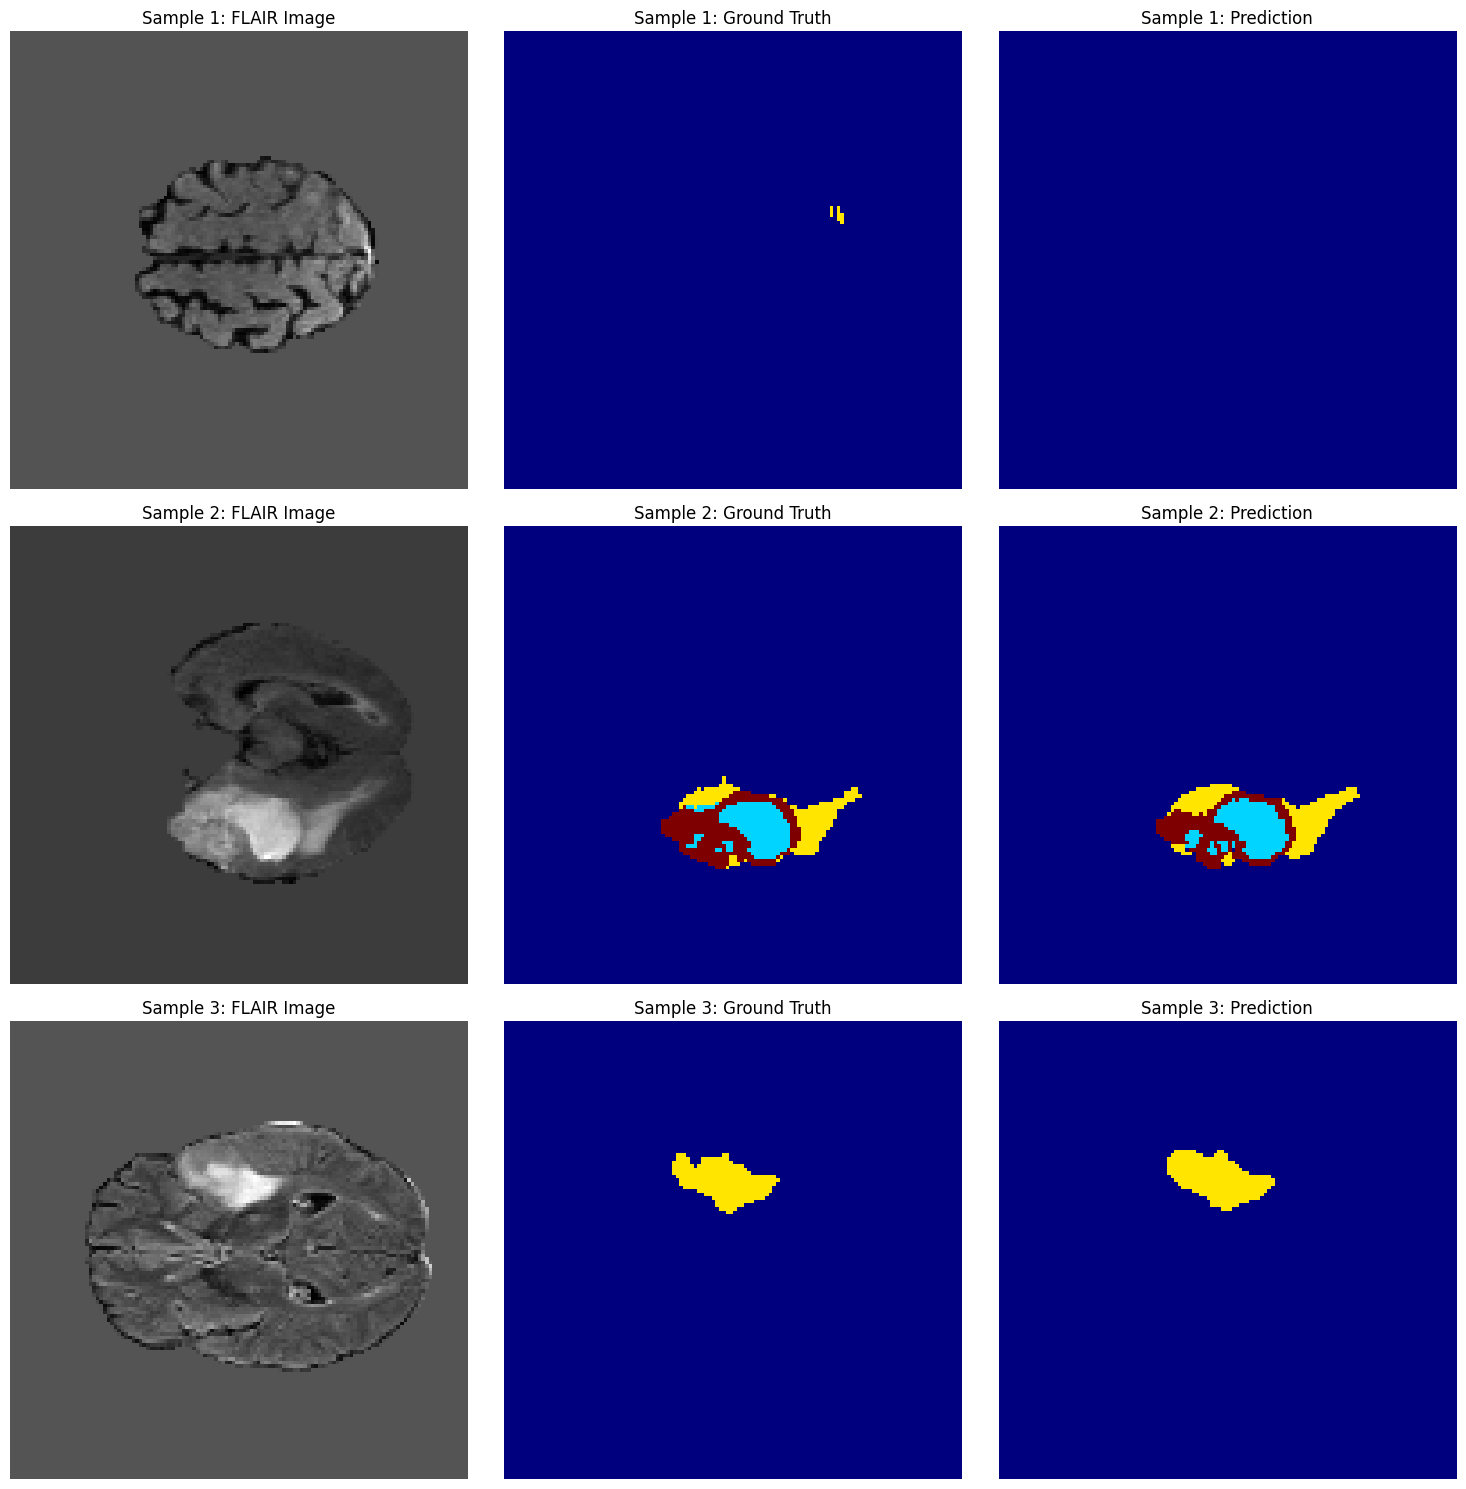

In [ ]:

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def visualize_predictions(model, test_loader, num_samples=3):
    model.eval()

    cmap = plt.get_cmap('jet', 4)

    images, masks = next(iter(test_loader))
    images, masks = images.to(device), masks.to(device)

    with torch.no_grad():
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        confidence, preds = probs.max(dim=1)
        CONFIDENCE_THRESHOLD = 0.5
        preds[confidence < CONFIDENCE_THRESHOLD] = 0


    images = images.cpu().numpy()
    masks = masks.cpu().numpy()
    preds = preds.cpu().numpy()

    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))

    for i in range(num_samples):

        axes[i, 0].imshow(images[i, 3, :, :], cmap='gray')
        axes[i, 0].set_title(f"Sample {i+1}: FLAIR Image")
        axes[i, 0].axis('off')


        im1 = axes[i, 1].imshow(masks[i], cmap=cmap, vmin=0, vmax=3)
        axes[i, 1].set_title(f"Sample {i+1}: Ground Truth")
        axes[i, 1].axis('off')

        # Model Prediction
        im2 = axes[i, 2].imshow(preds[i], cmap=cmap, vmin=0, vmax=3)
        axes[i, 2].set_title(f"Sample {i+1}: Prediction")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_predictions(model, test_loader, num_samples=3)

**Preparation for Classification**

Mask the tumor area into  128x128 images to be used in classification

In [ ]:

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def extract_tumor(image_tensor, mask_tensor, target_size=(128, 128)):

    binary_mask = (mask_tensor > 0).float()

    if binary_mask.sum() == 0:
        return torch.zeros((image_tensor.shape[0], target_size[0], target_size[1]))

    masked_image = image_tensor * binary_mask.unsqueeze(0)

    y_indices, x_indices = torch.where(binary_mask > 0)
    y_min, y_max = y_indices.min().item(), y_indices.max().item()
    x_min, x_max = x_indices.min().item(), x_indices.max().item()

    padding = 5
    y_min = max(0, y_min - padding)
    y_max = min(mask_tensor.shape[0], y_max + padding)
    x_min = max(0, x_min - padding)
    x_max = min(mask_tensor.shape[1], x_max + padding)

    cropped_tumor = masked_image[:, y_min:y_max, x_min:x_max]


    cropped_tumor = cropped_tumor.unsqueeze(0)
    resized_tumor = F.interpolate(cropped_tumor, size=target_size, mode='bilinear', align_corners=False)

    return resized_tumor.squeeze(0)

print("Tumor extraction function defined.")

Tumor extraction function defined.


Visualizing the masking we've done- make sure no tumor is cut out!

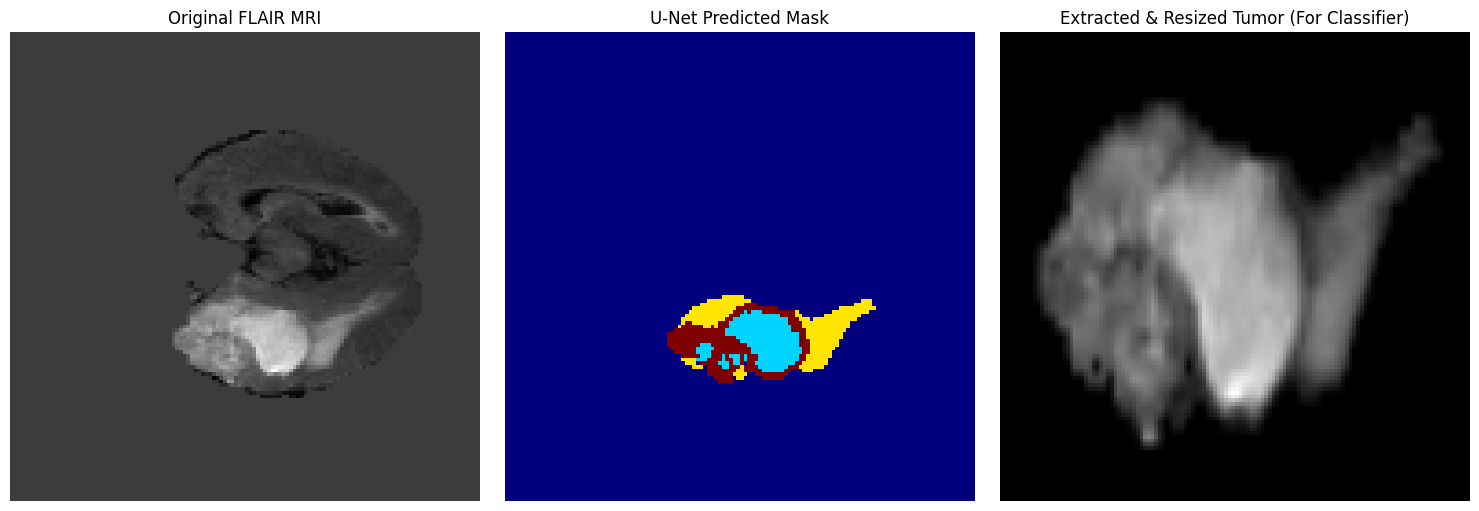

In [ ]:

def visualize_extraction(model, test_loader):
    model.eval()

    images, true_masks = next(iter(test_loader))
    images = images.to(device)


    with torch.no_grad():
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        confidence, pred_masks = probs.max(dim=1)
        pred_masks[confidence < 0.5] = 0

    images = images.cpu()
    pred_masks = pred_masks.cpu()

    idx = 0
    for i in range(images.shape[0]):
        if pred_masks[i].sum() > 0:
            idx = i
            break

    original_img = images[idx]
    pred_mask = pred_masks[idx]


    extracted_tumor = extract_tumor(original_img, pred_mask, target_size=(128, 128))


    fig, axes = plt.subplots(1, 3, figsize=(15, 5))


    axes[0].imshow(original_img[3].numpy(), cmap='gray')
    axes[0].set_title("Original FLAIR MRI")
    axes[0].axis('off')


    axes[1].imshow(pred_mask.numpy(), cmap='jet', vmin=0, vmax=3)
    axes[1].set_title("U-Net Predicted Mask")
    axes[1].axis('off')

    axes[2].imshow(extracted_tumor[3].numpy(), cmap='gray')
    axes[2].set_title("Extracted & Resized Tumor (For Classifier)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

visualize_extraction(model, test_loader)

Final formatting for classification: 2D arrays for tensors used in deep learning step and 1d arrays for machine learning.

In [ ]:

import numpy as np

def prepare_classification_dataset_with_labels(unet_model, dataloader, device):
    unet_model.eval()
    dl_features, label_list = [], []
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            outputs = unet_model(images)

            # Apply confidence threshold (Fix #3)
            probs = torch.softmax(outputs, dim=1)
            confidence, pred_masks = probs.max(dim=1)
            pred_masks[confidence < 0.5] = 0

            images, pred_masks = images.cpu(), pred_masks.cpu()
            for j in range(images.shape[0]):
                mask = pred_masks[j]
                tumor_pixels = mask[mask > 0]
                if tumor_pixels.numel() == 0:
                    continue  # skip BOTH feature and label together
                dominant_class = torch.mode(tumor_pixels).values.item()
                extracted = extract_tumor(images[j], mask, target_size=(64, 64))
                dl_features.append(extracted)
                label_list.append(dominant_class - 1)  # shift 1-3 → 0-2
    return torch.stack(dl_features), torch.tensor(label_list, dtype=torch.long)

print("Combined feature extraction + labeling function defined.")

Combined feature extraction + labeling function defined.


Classifiers resnet-18 with added 4th channel (deeplearning)

labelling - add dominant class label per patch and combine patches with the generated labels

In [ ]:

import torchvision.models as models
from torch.utils.data import TensorDataset

#initialising needed variables

class_name = ['NCR/NET', 'Edema', 'Enhancing Tumor'] #CLASS_NAMES
class_num = 3 #NUM_CLASSES
batch_size_rn = 64 #RESNET_BATCH
epochs_rn = 8 #RESNET_EPOCHS
LR_rn = 0.001 #RESNET_LR
resnet_save_path = './best_resnet_tumor_classifier.pth'

#assigning labels to each patch extracted from the previous steps
#def labels(unet_model, dataloader, device): #generate_labels
 #   unet_model.eval()
  #  labels = []

   # with torch.no_grad():
    #       images = images.to(device)
     #       outputs = unet_model(images)
      #      pred_masks = torch.argmax(outputs, dim=1).cpu()

       #     for j in range(images.shape[0]):
        #        mask = pred_masks[j]
         #       tumor_pixels = mask[mask > 0]

          #      if tumor_pixels.numel() == 0:
           #         continue

            #    dominant_class = torch.mode(tumor_pixels).values.item()
             #   labels.append(dominant_class)

#    labels = torch.tensor(labels, dtype=torch.long) - 1
 #   return labels

import random as _r
_r.seed(42)

train_loader_small = DataLoader(
    torch.utils.data.Subset(train_dataset, _r.sample(range(len(train_dataset)), min(2000, len(train_dataset)))),
    batch_size=64, shuffle=False, num_workers=1
)
val_loader_small = DataLoader(
    torch.utils.data.Subset(val_dataset, _r.sample(range(len(val_dataset)), min(500, len(val_dataset)))),
    batch_size=64, shuffle=False, num_workers=1
)
test_loader_small = DataLoader(
    torch.utils.data.Subset(test_dataset, _r.sample(range(len(test_dataset)), min(500, len(test_dataset)))),
    batch_size=64, shuffle=False, num_workers=1
)

train_features, train_labels = prepare_classification_dataset_with_labels(model, train_loader_small, device)
val_features,   val_labels   = prepare_classification_dataset_with_labels(model, val_loader_small,   device)
test_features,  test_labels  = prepare_classification_dataset_with_labels(model, test_loader_small,  device)

print("Label distribution:", torch.bincount(train_labels))
assert len(torch.bincount(train_labels)) == 3, "Missing classes in subsample — increase subset size or re-run"

Label distribution: tensor([ 118, 1555,  260])


ResNet-18 model function (from 3 to 4 input channels since there are 4 modalities in this dataset)

In [ ]:

class ResNet18(nn.Module): #TumourResNet

    def __init__(self, classes_num=3):
        super().__init__()

        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) #backbone
        resnet.conv1 = nn.Conv2d(in_channels=4, out_channels=64, kernel_size=3, stride=1, padding=1, bias=False)
        resnet.maxpool = nn.Identity() #maxpooling layer removed and switched with idenity (too less pixels left otherwise)
        resnet.fc = nn.Sequential(nn.Dropout(p=0.5), nn.Linear(512, 128),nn.ReLU(inplace=True),nn.Linear(128, classes_num))

        self.resnet = resnet

    def forward(self, x):
        return self.resnet(x)

loading data for classifier

In [ ]:

rn_train_loader = DataLoader(TensorDataset(train_features[:len(train_labels)], train_labels), batch_size=batch_size_rn, shuffle=True)
rn_val_loader   = DataLoader(TensorDataset(val_features[:len(val_labels)], val_labels),       batch_size=batch_size_rn, shuffle=False)
rn_test_loader  = DataLoader(TensorDataset(test_features[:len(test_labels)], test_labels),    batch_size=batch_size_rn, shuffle=False)


Model preperation ; class imbalance handling as done before for U Net + optimiser

In [ ]:

rn_model = ResNet18(classes_num=class_num).to(device)

rn_class_counts  = torch.bincount(train_labels, minlength=class_num).float()
rn_class_weights = 1.0 / (rn_class_counts + 1e-8)
rn_class_weights = (rn_class_weights / rn_class_weights.sum() * class_num).to(device)

rn_criterion = nn.CrossEntropyLoss(weight=rn_class_weights)
rn_optimizer = optim.AdamW(rn_model.parameters(), lr=LR_rn, weight_decay=1e-4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 151MB/s]


In [ ]:
# ResNet LR Sweep
import matplotlib.pyplot as plt
import torch.optim as optim

lr_candidates = [1e-2, 1e-3, 1e-4]
lr_results = {}

print("Running LR sweep for ResNet-18 (3 epochs each)...\n")

for lr_candidate in lr_candidates:
    sweep_model     = ResNet18(classes_num=class_num).to(device)
    sweep_criterion = nn.CrossEntropyLoss(weight=rn_class_weights)
    sweep_optimizer = optim.AdamW(sweep_model.parameters(), lr=lr_candidate, weight_decay=1e-4)

    sweep_val_losses = []

    for ep in range(3):
        sweep_model.train()
        for patches, lbls in rn_train_loader:
            patches, lbls = patches.to(device), lbls.to(device)
            sweep_optimizer.zero_grad()
            loss = sweep_criterion(sweep_model(patches), lbls)
            loss.backward()
            sweep_optimizer.step()

        sweep_model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for patches, lbls in rn_val_loader:
                patches, lbls = patches.to(device), lbls.to(device)
                val_loss_sum += sweep_criterion(sweep_model(patches), lbls).item()
        avg_vl = val_loss_sum / len(rn_val_loader)
        sweep_val_losses.append(avg_vl)
        print(f"  LR={lr_candidate:.0e} | Epoch {ep+1}/3 | Val Loss: {avg_vl:.4f}")

    lr_results[lr_candidate] = min(sweep_val_losses)
    del sweep_model, sweep_optimizer

best_lr = min(lr_results, key=lr_results.get)

print(f"\n{'LR':>10} | {'Best Val Loss':>14}")
print("-" * 28)
for lr_val, vl in lr_results.items():
    marker = " <-- BEST" if lr_val == best_lr else ""
    print(f"{lr_val:>10.0e} | {vl:>14.4f}{marker}")

print(f"\nBest LR found: {best_lr}")
LR_rn = best_lr
print(f"LR_rn updated to {LR_rn} — the training cell below will use this automatically")

Running LR sweep for ResNet-18 (3 epochs each)...

  LR=1e-02 | Epoch 1/3 | Val Loss: 15.0867
  LR=1e-02 | Epoch 2/3 | Val Loss: 0.8039
  LR=1e-02 | Epoch 3/3 | Val Loss: 0.9198
  LR=1e-03 | Epoch 1/3 | Val Loss: 1.1135
  LR=1e-03 | Epoch 2/3 | Val Loss: 1.2363
  LR=1e-03 | Epoch 3/3 | Val Loss: 0.5251
  LR=1e-04 | Epoch 1/3 | Val Loss: 0.6703
  LR=1e-04 | Epoch 2/3 | Val Loss: 0.5615
  LR=1e-04 | Epoch 3/3 | Val Loss: 0.3342

        LR |  Best Val Loss
----------------------------
     1e-02 |         0.8039
     1e-03 |         0.5251
     1e-04 |         0.3342 <-- BEST

Best LR found: 0.0001
LR_rn updated to 0.0001 — the training cell below will use this automatically


Training and Validation

In [ ]:

# Use best LR from sweep
LR_rn = best_lr  # 0.0001 from sweep
rn_optimizer = optim.AdamW(rn_model.parameters(), lr=LR_rn, weight_decay=1e-4)

best_val_loss = float('inf')
rn_history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print(f"\nStarting training for {epochs_rn} epochs\n")

patience = 2
trigger_times = 0
for epoch in range(epochs_rn):

    # training
    rn_model.train()
    running_loss = 0.0

    train_loop = tqdm(rn_train_loader, desc=f"Epoch {epoch+1}/{epochs_rn} [Train]")
    for patches, lbls in train_loop:
        patches, lbls = patches.to(device), lbls.to(device)

        rn_optimizer.zero_grad()
        logits = rn_model(patches)
        loss   = rn_criterion(logits, lbls)
        loss.backward()
        rn_optimizer.step()

        running_loss += loss.item()
        train_loop.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = running_loss / len(rn_train_loader)

    # validation
    rn_model.eval()
    val_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for patches, lbls in rn_val_loader:
            patches, lbls = patches.to(device), lbls.to(device)
            logits = rn_model(patches)
            loss   = rn_criterion(logits, lbls)
            val_loss += loss.item()
            preds    = torch.argmax(logits, dim=1)
            correct += (preds == lbls).sum().item()
            total   += lbls.size(0)

    avg_val_loss = val_loss / len(rn_val_loader)
    val_accuracy = correct / total

    rn_history['train_loss'].append(avg_train_loss)
    rn_history['val_loss'].append(avg_val_loss)
    rn_history['val_acc'].append(val_accuracy)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(rn_model.state_dict(), resnet_save_path)
        saved_tag = " → [SAVED]"
        trigger_times = 0
    else:
        trigger_times += 1
        saved_tag = ""

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {val_accuracy*100:.2f}%{saved_tag}")

    if trigger_times >= patience:
        print(f"\n[EARLY STOPPING] No improvement for {patience} epochs. Breaking at Epoch {epoch+1}")
        break

print("\nResNet training complete")


Starting training for 8 epochs



Epoch 1/8 [Train]: 100%|██████████| 31/31 [00:05<00:00,  5.23it/s, loss=0.9877]


Epoch 01 | Train Loss: 0.7604 | Val Loss: 0.4938 | Val Acc: 84.74% → [SAVED]


Epoch 2/8 [Train]: 100%|██████████| 31/31 [00:05<00:00,  5.18it/s, loss=0.3675]


Epoch 02 | Train Loss: 0.3325 | Val Loss: 0.3605 | Val Acc: 88.45% → [SAVED]


...

Epoch 03 | Train Loss: 0.1494 | Val Loss: 0.3062 | Val Acc: 87.22% → [SAVED]


Epoch 4/8 [Train]: 100%|██████████| 31/31 [00:06<00:00,  5.05it/s, loss=0.2481]


Epoch 04 | Train Loss: 0.0851 | Val Loss: 0.4023 | Val Acc: 90.31%


Epoch 5/8 [Train]: 100%|██████████| 31/31 [00:06<00:00,  5.00it/s, loss=0.1171]


Epoch 05 | Train Loss: 0.0707 | Val Loss: 0.4407 | Val Acc: 88.45%

[EARLY STOPPING] No improvement for 2 epochs. Breaking at Epoch 5

ResNet training complete


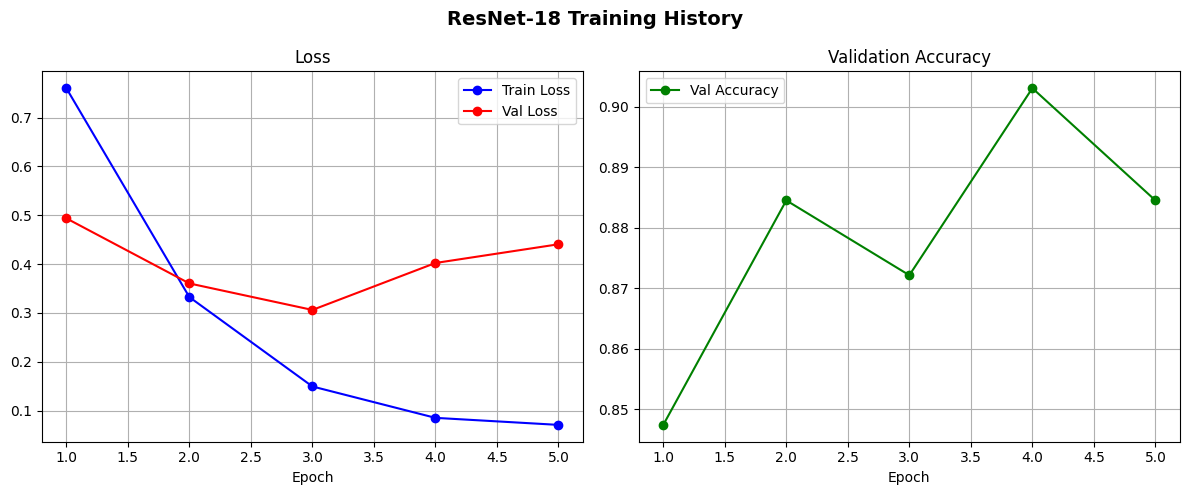

In [ ]:
# Plot ResNet Training Curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('ResNet-18 Training History', fontsize=14, fontweight='bold')

rn_epochs_range = range(1, len(rn_history['train_loss']) + 1)

axes[0].plot(rn_epochs_range, rn_history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(rn_epochs_range, rn_history['val_loss'],   'r-o', label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(rn_epochs_range, rn_history['val_acc'], 'g-o', label='Val Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Testing

In [ ]:

rn_model.load_state_dict(torch.load(resnet_save_path, map_location=device))
rn_model.eval()

all_preds_list   = []
all_labels_list  = []
all_patches_list = []

with torch.no_grad():
    for patches, lbls in rn_test_loader:
        patches, lbls = patches.to(device), lbls.to(device)
        logits = rn_model(patches)
        preds  = torch.argmax(logits, dim=1)

        all_preds_list.append(preds.cpu())
        all_labels_list.append(lbls.cpu())
        all_patches_list.append(patches.cpu())

all_preds   = torch.cat(all_preds_list).numpy()
all_labels  = torch.cat(all_labels_list).numpy()
all_patches = torch.cat(all_patches_list)

plotting confusion matrices

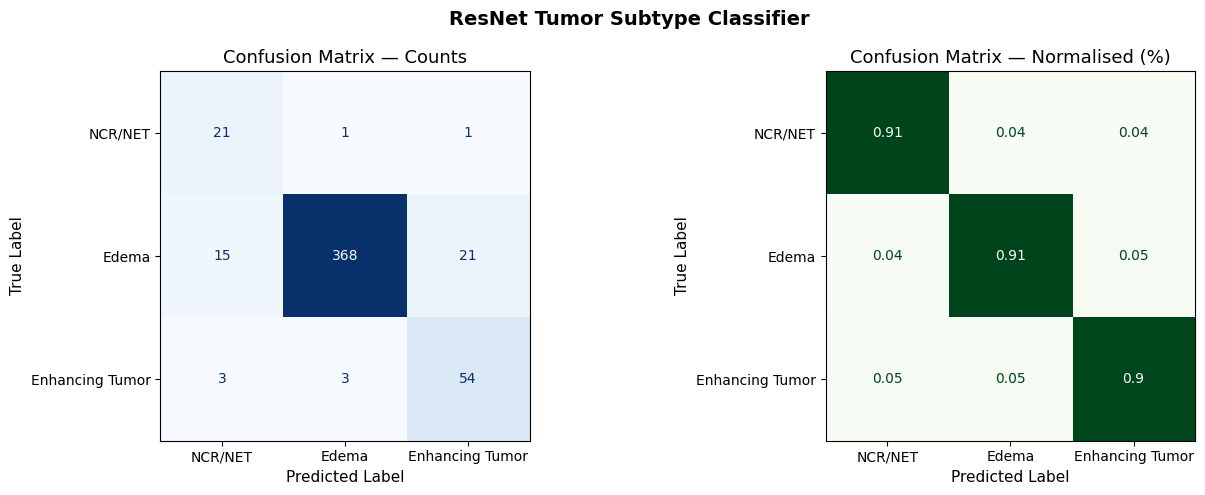

In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig_cm, axes_cm = plt.subplots(1, 2, figsize=(14, 5))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_name)
disp1.plot(ax=axes_cm[0], colorbar=False, cmap='Blues')
axes_cm[0].set_title('Confusion Matrix — Counts', fontsize=13)
axes_cm[0].set_xlabel('Predicted Label', fontsize=11)
axes_cm[0].set_ylabel('True Label', fontsize=11)

disp2 = ConfusionMatrixDisplay(
    confusion_matrix=np.round(cm_norm, 2), display_labels=class_name
)
disp2.plot(ax=axes_cm[1], colorbar=False, cmap='Greens')
axes_cm[1].set_title('Confusion Matrix — Normalised (%)', fontsize=13)
axes_cm[1].set_xlabel('Predicted Label', fontsize=11)
axes_cm[1].set_ylabel('True Label', fontsize=11)

plt.suptitle('ResNet Tumor Subtype Classifier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

classification matrices

In [ ]:

from sklearn.metrics import precision_score, recall_score

precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
recall    = recall_score(all_labels, all_preds, average=None, zero_division=0)

print(f"  {'Class':<22} {'Precision':>10} {'Recall':>10} {'Accuracy':>10}")

for c in range(class_num):
    mask    = (all_labels == c)
    cls_acc = (all_preds[mask] == c).sum() / mask.sum() if mask.sum() > 0 else 0.0
    print(f"  {class_name[c]:<22} {precision[c]:>10.4f} {recall[c]:>10.4f} {cls_acc:>10.4f}")

print(f"  {'Macro Average':<22} {precision.mean():>10.4f} {recall.mean():>10.4f}")
print(f"  {'Overall Accuracy':<22} {'':>10} {'':>10} {(all_preds == all_labels).mean():>10.4f}")

  Class                   Precision     Recall   Accuracy
  NCR/NET                    0.5385     0.9130     0.9130
  Edema                      0.9892     0.9109     0.9109
  Enhancing Tumor            0.7105     0.9000     0.9000
  Macro Average              0.7461     0.9080
  Overall Accuracy                                 0.9097


ground truth vs prediction 3 samples per class

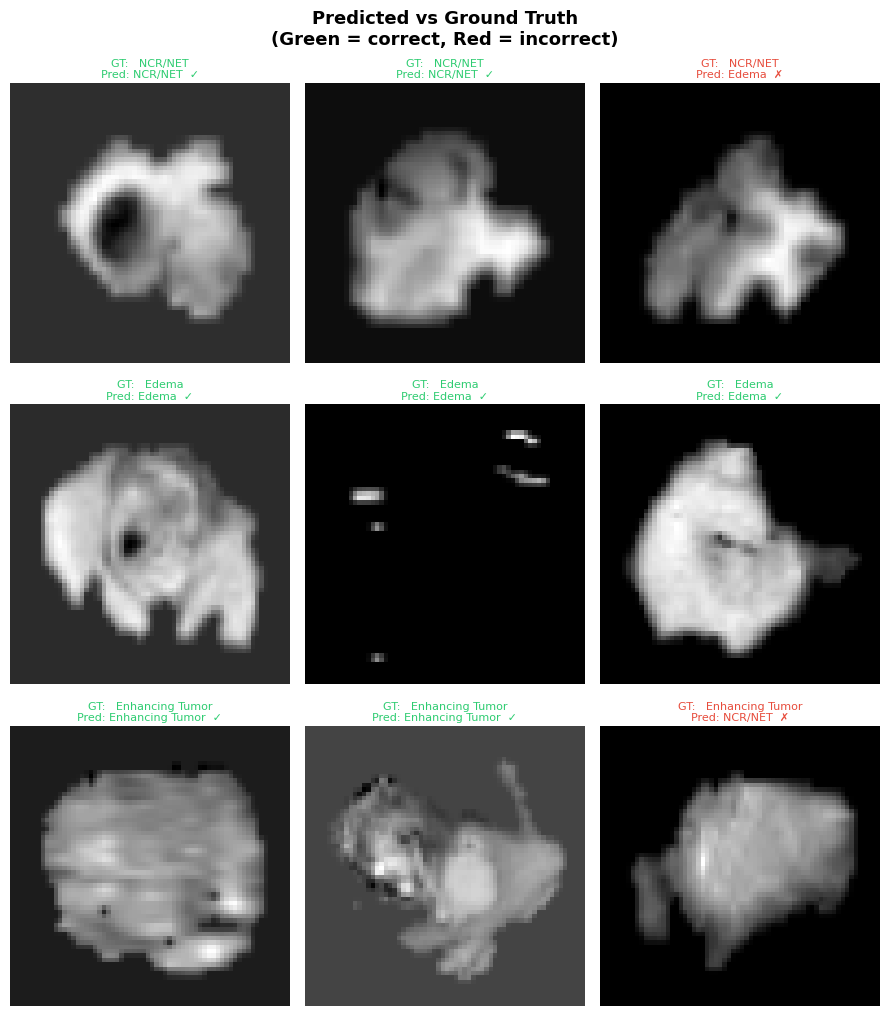

In [ ]:

per_class_smp = 3

fig, axes = plt.subplots(
    class_num, per_class_smp,
    figsize=(per_class_smp * 3, class_num * 3.5)
)
fig.suptitle(
    'Predicted vs Ground Truth\n'
    '(Green = correct, Red = incorrect)',
    fontsize=13, fontweight='bold'
)

np.random.seed(42)

for row, cls in enumerate(range(class_num)):
    cls_idxs = np.where(all_labels == cls)[0]
    chosen   = np.random.choice(
        cls_idxs, size=min(per_class_smp, len(cls_idxs)), replace=False
    )

    while len(chosen) < per_class_smp:
        chosen = np.append(chosen, -1)

    for col, idx in enumerate(chosen):
        ax = axes[row, col]

        if idx == -1:
            ax.axis('off')
            continue

        flair   = all_patches[idx, 3].numpy()
        true_c  = all_labels[idx]
        pred_c  = all_preds[idx]
        correct = (true_c == pred_c)
        color   = '#2ecc71' if correct else '#e74c3c'
        symbol  = '✓' if correct else '✗'

        ax.imshow(flair, cmap='gray')
        ax.axis('off')

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(color)
            spine.set_linewidth(4)

        ax.set_title(
            f"GT:   {class_name[true_c]}\n"
            f"Pred: {class_name[pred_c]}  {symbol}",
            fontsize=8, color=color, pad=4
        )

    axes[row, 0].set_ylabel(
        f"True:\n{class_name[cls]}",
        fontsize=9, fontweight='bold', labelpad=6
    )

plt.tight_layout()
plt.show()

Comparing with a Machine Learning Classifer like random forest.
I will use the features preparation of Tuna's part.

In [ ]:
train_ml_features = train_features.numpy().reshape(len(train_features), -1)
val_ml_features   = val_features.numpy().reshape(len(val_features), -1)
test_ml_features  = test_features.numpy().reshape(len(test_features), -1)

print(f"Train: {train_ml_features.shape}")
print(f"Val:   {val_ml_features.shape}")
print(f"Test:  {test_ml_features.shape}")

Train: (1933, 16384)
Val:   (485, 16384)
Test:  (487, 16384)


training on random forest

In [ ]:
# Random Forest with GridSearchCV
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
import time

train_ml_filtered = train_ml_features[:len(train_labels)]
val_ml_filtered   = val_ml_features[:len(val_labels)]
test_ml_filtered  = test_ml_features[:len(test_labels)]

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [None, 10, 20],
    'max_features': ['sqrt', 'log2'],
}

print("Running GridSearchCV for Random Forest (this may take a few minutes)...")
start = time.time()

rf_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1
)
rf_search.fit(train_ml_filtered, train_labels.numpy())

print(f"\nSearch complete in {time.time()-start:.0f}s")
print(f"Best params:  {rf_search.best_params_}")
print(f"Best CV F1:   {rf_search.best_score_:.4f}")

best_rf = rf_search.best_estimator_
rf_preds = best_rf.predict(test_ml_filtered)

print("\n===== Random Forest Test Results (Best Model) =====")
print(classification_report(test_labels.numpy(), rf_preds, target_names=class_name))

Running GridSearchCV for Random Forest (this may take a few minutes)...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Search complete in 203s
Best params:  {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV F1:   0.5907

===== Random Forest Test Results (Best Model) =====
                 precision    recall  f1-score   support

        NCR/NET       0.79      0.48      0.59        23
          Edema       0.89      0.99      0.94       404
Enhancing Tumor       0.89      0.42      0.57        60

       accuracy                           0.89       487
      macro avg       0.86      0.63      0.70       487
   weighted avg       0.89      0.89      0.88       487



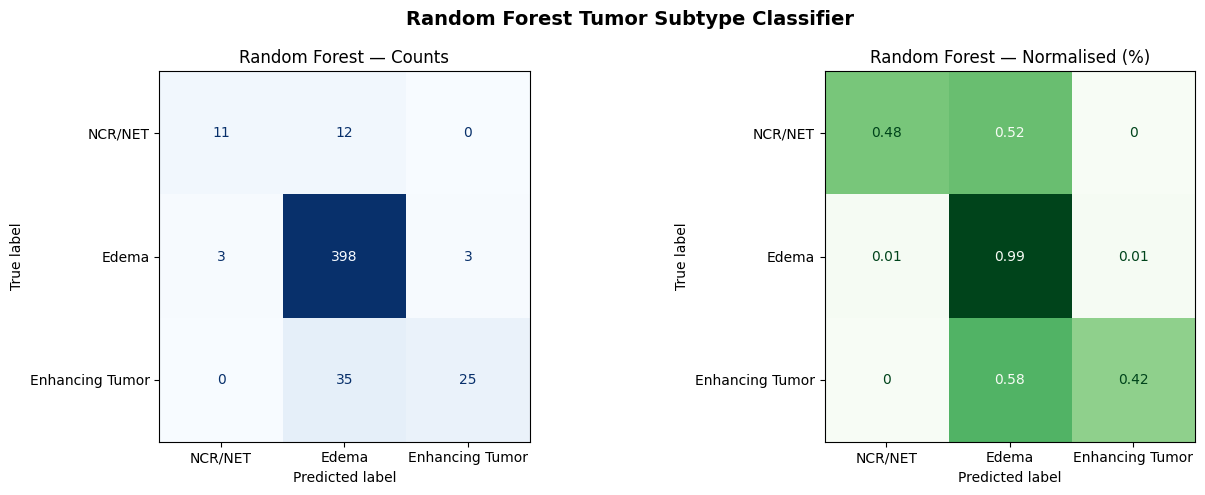

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm      = confusion_matrix(test_labels.numpy(), rf_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm, display_labels=class_name).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Random Forest — Counts')

ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=class_name).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Random Forest — Normalised (%)')

plt.suptitle('Random Forest Tumor Subtype Classifier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()